In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("data/sensor_data.csv")

In [3]:
print (df.shape)


(10000, 14)


In [5]:
print(df.head())
print(df.tail())
print(df.info())
print (df["Machine failure"].value_counts())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [6]:
import numpy as np

np.random.seed(42)
machine_ids = [f"EQ-{1000+i}" for i in range(10)]

df["Equipment_ID"] = np.random.choice(machine_ids, size=len(df))

equipment_master = pd.DataFrame({
    "Equipment_ID": machine_ids,
    "Plant": "1000",
    "Work_Center": np.random.choice(["WC-A", "WC-B", "WC-C"], size=10),
    "Machine_Type": np.random.choice(["CNC Mill", "Lathe", "Press"], size=10)
})

equipment_master.to_csv("data/sap_equipment_master.csv", index=False)
df.to_csv("data/sensor_data_with_equipment.csv", index=False)

print(equipment_master)
print(df.columns.tolist()) 

  Equipment_ID Plant Work_Center Machine_Type
0      EQ-1000  1000        WC-C     CNC Mill
1      EQ-1001  1000        WC-B     CNC Mill
2      EQ-1002  1000        WC-C     CNC Mill
3      EQ-1003  1000        WC-A     CNC Mill
4      EQ-1004  1000        WC-B     CNC Mill
5      EQ-1005  1000        WC-C     CNC Mill
6      EQ-1006  1000        WC-C        Lathe
7      EQ-1007  1000        WC-B     CNC Mill
8      EQ-1008  1000        WC-C        Press
9      EQ-1009  1000        WC-C        Lathe
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Equipment_ID']


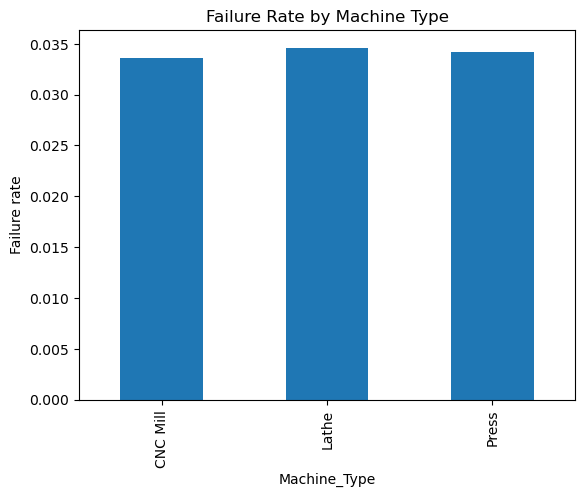

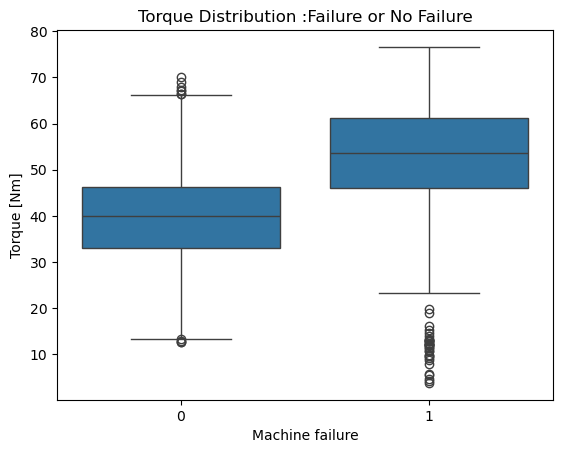

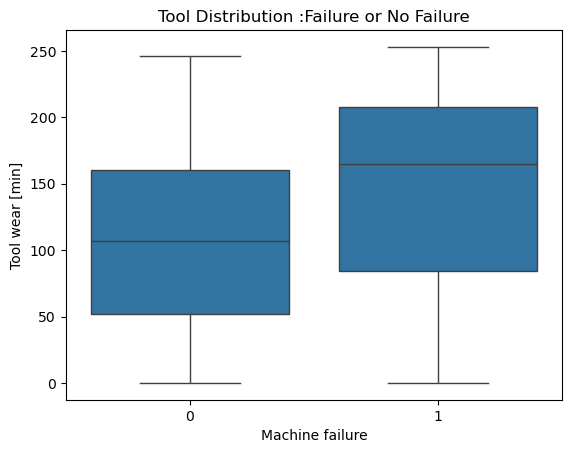

In [15]:
import seaborn as sns 
import matplotlib.pyplot as plt
merged = df.merge(equipment_master,on="Equipment_ID")

fail_by_type=merged.groupby("Machine_Type")["Machine failure"].mean()
fail_by_type.plot(kind="bar",title="Failure Rate by Machine Type")
plt.ylabel("Failure rate")
plt.show()

sns.boxplot(data=df,x="Machine failure",y="Torque [Nm]")
plt.title("Torque Distribution :Failure or No Failure")
plt.show()

sns.boxplot(data=df,x="Machine failure",y="Tool wear [min]")
plt.title("Tool Distribution :Failure or No Failure")
plt.show()